# 02 · Forma y fuerza: series temporales por equipo

**Objetivo:** construir, partido a partido y **solo con información anterior a cada partido**, dos series por equipo:

1. **Fuerza a largo plazo:** un Elo propio.
2. **Forma a corto plazo:** medias móviles de rendimiento.

⚠️ **Riesgo principal de esta fase: la fuga de información.** Si la "forma antes del partido" incluye ese mismo partido, el modelo de la fase 4 acertará de maravilla… con trampa.

**Decisiones del Elo**

| Decisión | Elección | Motivo |
|---|---|---|
| Componentes | Base (K + ventaja de local H fija) + multiplicador por margen de goles | El margen aporta información; más componentes = más parámetros que justificar |
| Cómo se fijan los valores | A priori, sin ajustarlos a nuestros datos | Evitar *data snooping*: un Elo de 2015 no puede estar calibrado con lo que pasó en 2025 |
| K | 20 | Valor habitual en adaptaciones de Elo a ligas de clubes |
| Margen de goles | ×1 (1 gol), ×1,5 (2 goles), ×(11+N)/8 (N ≥ 3 goles) | World Football Elo Ratings (eloratings.net) |
| H (ventaja de local) | 65 puntos Elo | Valor moderado elegido **a priori**, por debajo de los 100 de eloratings.net (pensado para selecciones). No se reajusta tras ver los datos |
| Valor inicial | 1500 para todos en 2012/13 | Estándar; las dos temporadas de calentamiento lo estabilizan |
| Ascendidos | Heredan el Elo medio de los descendidos de la temporada anterior (también si ya estuvieron en Primera) + K × 1,5 en sus primeras 5 jornadas | Una sola regla; no sabemos cómo les fue en Segunda |
| Regresión a la media en verano | No | Limitación documentada: el Elo tarda en reflejar los cambios de plantilla |

**Decisiones de la forma**

| Decisión | Elección | Motivo |
|---|---|---|
| Variables | Forma según **resultados** (puntos por partido) y según **rendimiento** (diferencia de xG) | Comparar ambas separa el buen momento real de la suerte |
| Ventana | Últimos 5 partidos, media simple | Estándar y fácil de explicar. Limitación: ruido y sensibilidad a extremos |
| Entre temporadas | La ventana continúa en verano… | Todos tienen forma desde la jornada 1, salvo los ascendidos |
| …dentro de cada etapa en Primera | Se reinicia si un equipo vuelve tras descender | Coherente con "siempre A2": un ascendido no usa su historial antiguo |
| Ascendidos | K × 1,5 y exclusión del modelo durante sus primeros 5 partidos | Misma N que la ventana: una sola regla |

**Decisiones del análisis de rachas**

| Decisión | Elección | Motivo |
|---|---|---|
| Qué es una racha | Sorpresas del mismo signo seguidas (resultado − puntuación esperada por el Elo) | Una racha "bruta" confunde racha con calidad (la moneda trucada) |
| Cómo se mide | Autocorrelación de 1 a 10 partidos, del resultado bruto (contraste) y de la sorpresa | La autocorrelación responde directamente a "cuánto dura" |
| Ascendidos | Se excluyen sus 5 primeros partidos | Sus sorpresas positivas son un sesgo del Elo (A2), no una racha |
| Resultados vs. juego | ¿Qué anticipa mejor los puntos de los 5 partidos siguientes: la forma en puntos o la forma en xG? | Separa el momento real del azar |
| Incertidumbre | *Bootstrap* por equipo-temporada | Las ventanas se solapan: las filas no son independientes |


## 0. Preparación

In [1]:
import sys
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent
PROCESSED = ROOT / "data" / "processed"
FIGURES = ROOT / "reports" / "figures"
sys.path.insert(0, str(ROOT / "src"))        # funciones del proyecto: src/laliga/
from laliga.elo import (ELO_INICIAL, FACTOR_ASCENDIDO, H, K, N_FORMA, PUNTUACION, calcular_elo,
                        multiplicador_margen, puntuacion_esperada)

con = duckdb.connect(config={"threads": 1})   # un hilo: las sumas siempre en el mismo orden (resultados idénticos byte a byte)
con.sql(f"CREATE VIEW partidos AS SELECT * FROM read_csv('{(PROCESSED / 'partidos.csv').as_posix()}')")
con.sql(f"CREATE VIEW partidos_equipo AS SELECT * FROM read_csv('{(PROCESSED / 'partidos_equipo.csv').as_posix()}')")

# Colores del proyecto (mismos que en el notebook 01)
SERIE, TINTA, TINTA_2, FONDO, REJILLA = "#2a78d6", "#0b0b0b", "#52514e", "#fcfcfb", "#e4e3df"

con.sql("SELECT count(*) AS partidos, min(fecha) AS desde, max(fecha) AS hasta FROM partidos").df()

,partidos,desde,hasta
0,5320,2012-08-18,2026-05-24


## 1. ¿Cuánta ventaja da jugar en casa? (análisis descriptivo)

Antes de construir el Elo, miramos cómo ha evolucionado la ventaja de local. Medida: **puntuación media del local**, contando victoria = 1, empate = 0,5 y derrota = 0 (la misma escala que usa el Elo). Sin ventaja de local sería 0,5.

Para comparar, el valor H = 65 que elegimos implica que, entre dos equipos iguales, el local puntúa $E = 1/(1 + 10^{-65/400}) \approx 0{,}592$.

⚠️ **Esto es descriptivo.** H ya está fijada a priori; este gráfico **no** se usa para reajustarla.

In [2]:
E_H = 1 / (1 + 10 ** (-H / 400))

ventaja = con.sql("""
SELECT temporada,
       count(*)                                                  AS partidos,
       round(100 * avg(CASE WHEN resultado = '1' THEN 1 ELSE 0 END), 1) AS pct_victoria_local,
       round(100 * avg(CASE WHEN resultado = 'X' THEN 1 ELSE 0 END), 1) AS pct_empate,
       round(100 * avg(CASE WHEN resultado = '2' THEN 1 ELSE 0 END), 1) AS pct_victoria_visitante,
       avg(CASE resultado WHEN '1' THEN 1 WHEN 'X' THEN 0.5 ELSE 0 END)  AS puntuacion_local
FROM partidos
GROUP BY temporada
ORDER BY temporada
""").df()
# H equivalente: la ventaja en puntos Elo que produciría esa puntuación entre dos equipos iguales
ventaja["h_equivalente"] = (-400 * np.log10(1 / ventaja.puntuacion_local - 1)).round(0)
ventaja["puntuacion_local"] = ventaja.puntuacion_local.round(3)
ventaja

,temporada,partidos,pct_victoria_local,pct_empate,pct_victoria_visitante,puntuacion_local,h_equivalente
0,2012-13,380,49.7,22.1,28.2,0.608,76.0
1,2013-14,380,47.1,22.6,30.3,0.584,59.0
2,2014-15,380,45.0,23.9,31.1,0.570,49.0
3,2015-16,380,48.2,24.2,27.6,0.603,72.0
4,2016-17,380,47.6,23.4,28.9,0.593,66.0
5,2017-18,380,47.1,22.6,30.3,0.584,59.0
6,2018-19,380,44.2,28.9,26.8,0.587,61.0
7,2019-20,380,45.8,27.6,26.6,0.596,68.0
8,2020-21,380,41.6,28.7,29.7,0.559,41.0
9,2021-22,380,43.4,29.2,27.4,0.580,56.0


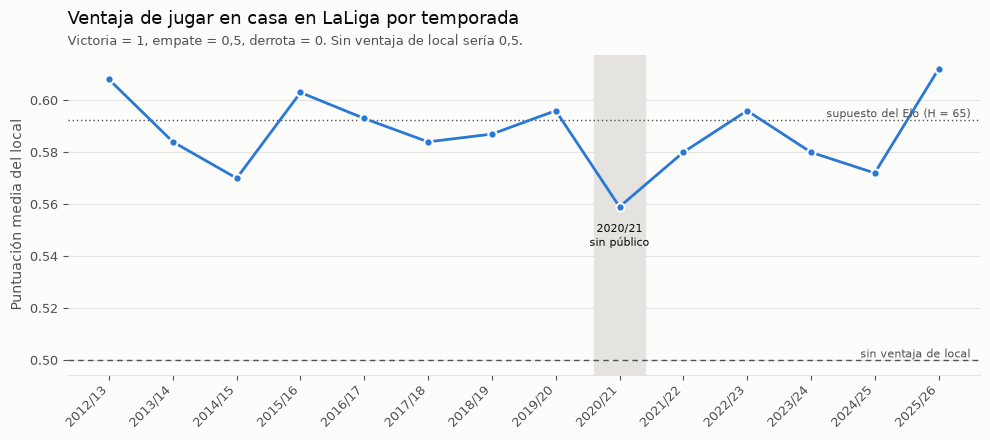

In [3]:
fig, ax = plt.subplots(figsize=(10, 4.5), facecolor=FONDO)
x = np.arange(len(ventaja))
ax.plot(x, ventaja.puntuacion_local, color=SERIE, linewidth=2, marker="o", markersize=6,
        markeredgecolor=FONDO, markeredgewidth=1.5, zorder=3)

ax.axhline(0.5, color=TINTA_2, linewidth=1, linestyle=(0, (4, 3)))
ax.text(len(x) - 0.5, 0.5, "sin ventaja de local", ha="right", va="bottom", fontsize=8, color=TINTA_2)
ax.axhline(E_H, color=TINTA_2, linewidth=1, linestyle=(0, (1, 2)))
ax.text(len(x) - 0.5, E_H, f"supuesto del Elo (H = {H})", ha="right", va="bottom", fontsize=8, color=TINTA_2)

covid = ventaja.index[ventaja.temporada == "2020-21"][0]
ax.axvspan(covid - 0.4, covid + 0.4, color=REJILLA, zorder=0)
ax.annotate("2020/21\nsin público", xy=(covid, ventaja.puntuacion_local[covid]),
            xytext=(covid, ventaja.puntuacion_local[covid] - 0.006), ha="center", va="top",
            fontsize=8, color=TINTA)

ax.set_xticks(x, [t.replace("-", "/") for t in ventaja.temporada], rotation=45, ha="right")
ax.set_ylabel("Puntuación media del local", color=TINTA_2)
ax.set_facecolor(FONDO)
ax.grid(axis="y", color=REJILLA, linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(colors=TINTA_2, labelsize=9)
for lado in ("top", "right", "left"):
    ax.spines[lado].set_visible(False)
ax.spines["bottom"].set_color(REJILLA)
ax.set_title("Ventaja de jugar en casa en LaLiga por temporada", loc="left", fontsize=13, color=TINTA, pad=22)
ax.text(0, 1.03, "Victoria = 1, empate = 0,5, derrota = 0. Sin ventaja de local sería 0,5.",
        transform=ax.transAxes, fontsize=9, color=TINTA_2)
fig.tight_layout()
fig.savefig(FIGURES / "02_ventaja_local.png", dpi=150, facecolor=FONDO)
plt.show()

**Qué vemos:**

- **La ventaja de local existe siempre:** la puntuación del local oscila entre 0,56 y 0,61 (sin ventaja sería 0,5). En puntos Elo equivale a entre 41 y 79, con una media en torno a 60.
- **2020/21, la temporada sin público, es el mínimo de la serie (0,559, equivalente a H ≈ 41)**, aunque la ventaja **no desaparece**: jugar en casa sigue ayudando sin afición (desplazamientos, familiaridad con el campo). En 2019/20 solo los partidos de junio y julio de 2020 fueron sin público, por eso su efecto se diluye en el total de la temporada.
- **H = 65 cae dentro del rango observado.** Transparencia: el valor se eligió **antes** de hacer este gráfico. Que encaje es una coincidencia, no un ajuste; y aunque no encajara, no lo cambiaríamos.

**Implicación para el Elo:** con H fija, en 2020/21 el Elo **sobrestima a los locales** (supone 0,592 cuando la realidad fue 0,559). Es una limitación conocida y documentada, y un ejemplo de **cambio de régimen** en una serie temporal: una condición externa cambia la relación entre las variables durante un periodo.

## 2. El Elo

### Qué es, en una frase

Un **número por equipo que resume su fuerza acumulada**. Antes de cada partido, la diferencia de Elo entre los dos equipos da un resultado esperado; después del partido, cada equipo gana o pierde puntos según lo que pasó **frente a lo que se esperaba**. Ganar a un rival fuerte da muchos puntos; ganar a uno débil, pocos. Nació para el ajedrez y se adapta al fútbol en webs como eloratings.net (selecciones) o ClubElo (clubes). No usamos ningún Elo publicado: lo calculamos nosotros para controlar exactamente qué información entra.

### Las tres fórmulas

1. **Puntuación esperada del local** (entre 0 y 1):
$$E = \frac{1}{1 + 10^{-\left(R_{local} + H - R_{visitante}\right)/400}}$$
2. **Resultado real:** $S = 1$ si gana el local, $0{,}5$ si empatan, $0$ si pierde.
3. **Actualización** (lo que gana uno lo pierde el otro):
$$R_{local}^{nuevo} = R_{local} + K \cdot G \cdot (S - E) \qquad R_{visitante}^{nuevo} = R_{visitante} - K \cdot G \cdot (S - E)$$

$G$ es el multiplicador por margen de goles: ×1 si se gana por 1 gol (o se empata), ×1,5 por 2 goles, ×(11 + N)/8 por N ≥ 3 goles.

### Nuestra implementación, parámetro a parámetro

| Pieza | Valor | Qué controla | Si fuera mayor… / menor… |
|---|---|---|---|
| **K** | 20 | Velocidad: cuántos puntos se mueven tras cada partido | Mayor: reacciona antes a un cambio real (fichajes, entrenador), pero también al ruido de un mal partido. Menor: más estable, pero tarda en enterarse de los cambios |
| **H** | 65 | Ventaja de campo en puntos Elo; se suma al local **solo** para calcular $E$ | Mayor: se espera más del local, así que ganar en casa da menos puntos y perder en casa quita más. Menor: lo contrario |
| **G** | 1 / 1,5 / (11+N)/8 | Cuánto pesa el margen de goles | Fórmula fija de eloratings.net |
| **Inicio** | 1500 para todos en 2012/13 | Punto de partida común | Las dos temporadas de calentamiento (2012/13–2013/14) sirven para que los valores se separen antes de analizar nada |
| **Ascendidos** | Heredan el Elo medio de los descendidos de la temporada anterior, con K × 1,5 en sus 5 primeros partidos | Qué fuerza se supone a un equipo sin historial reciente en Primera | La regla se aplica también a los que ya estuvieron en Primera años atrás (no usamos su Elo antiguo). Más abajo se comprueba cómo de bien funciona |
| **Verano** | Sin regresión a la media | Si el Elo "olvida" parte entre temporadas | Limitación: tarda en reflejar cambios de plantilla |

**Sobre H = 65 (decisión metodológica del proyecto).** Entre dos equipos iguales implica que el local espera 0,592 (sin ventaja sería 0,5). Es un valor **elegido por nosotros a priori**, moderado (por debajo de los 100 que usa eloratings.net para selecciones), **sin una fuente externa que lo respalde** y **nunca ajustado** a los datos: la sección 1 lo compara con la ventaja real solo de forma descriptiva. No es una constante "correcta": es un supuesto razonable y fijo. Dos matices importantes:

- **H no entra en el modelo 1X2 de la fase 4.** Allí la variable es `elo_dif` = Elo del local − Elo del visitante, **sin H**; la ventaja de local la estima el propio modelo con los datos de entrenamiento. H solo influye en **cómo se reparten los puntos** tras cada partido.
- **Un H algo desviado acumula poco error**, porque cada equipo juega la mitad de sus partidos en casa: lo que se le quita de más en casa se le devuelve fuera. Lo que no capta un H fijo es que la ventaja cambie en el tiempo (2020/21, sin público: equivalente a H ≈ 41).

### Cuándo se actualiza y qué se sabe en cada momento

Los partidos se recorren en orden cronológico (fecha y, a igualdad, identificador). Para **cada** partido:

```
Elo antes del partido   <- resume TODOS los partidos anteriores del equipo. Es lo único que se usa para predecir
      | se juega el partido (resultado y margen)
      v
Elo después del partido <- incluye este partido. Solo sirve como "Elo antes" del siguiente partido del equipo
```

Por eso `forma_elo.csv` exporta únicamente `elo_antes` y `elo_rival_antes`: el Elo "después" se deja fuera a propósito para que nadie lo use por error como variable.

### El algoritmo

El Elo es **secuencial**: cada partido modifica el estado (las puntuaciones) que usa el siguiente. Por eso no se calcula con SQL sino con un bucle en Python que recorre los partidos en orden cronológico:

```
Al empezar cada temporada:
    ascendidos  = equipos de esta temporada que no estaban en la anterior
    descendidos = equipos de la anterior que no están en esta
    cada ascendido recibe el Elo medio de los descendidos y K × 1,5 durante 5 partidos

Para cada partido:
    1. guardar el Elo ANTES del partido          ← esto es lo único que se puede usar para predecirlo
    2. E = puntuación esperada del local
    3. S = resultado real (1 / 0,5 / 0)
    4. Elo nuevo = Elo + K · multiplicador_margen · (S − E)
    5. guardar el Elo DESPUÉS del partido
```

**Ojo con un matiz:** E es la **puntuación esperada** (victoria = 1, empate = 0,5), no la probabilidad de ganar. Un E de 0,6 no significa "60 % de victoria local": los empates cuentan medio punto.

In [4]:
# El código del Elo está en src/laliga/elo.py (importado en la sección 0) para poder probarlo con pytest.
# Es exactamente el algoritmo descrito arriba: multiplicador_margen, puntuacion_esperada y calcular_elo.
print(f"K = {K} · H = {H} · factor ascendido = {FACTOR_ASCENDIDO} · N = {N_FORMA} · Elo inicial = {ELO_INICIAL}")

partidos_df = con.sql("SELECT * FROM partidos").df()
elo_partidos = calcular_elo(partidos_df)
elo_partidos.head()

K = 20 · H = 65 · factor ascendido = 1.5 · N = 5 · Elo inicial = 1500


,id_partido,temporada,elo_local_antes,elo_visitante_antes,puntuacion_esperada_local,elo_local_despues,elo_visitante_despues,periodo_ascenso_local,periodo_ascenso_visitante
0,1,2012-13,1500.0,1500.0,0.592466,1488.150675,1511.849325,False,False
1,2,2012-13,1500.0,1500.0,0.592466,1508.150675,1491.849325,False,False
2,3,2012-13,1500.0,1500.0,0.592466,1508.150675,1491.849325,False,False
3,4,2012-13,1500.0,1500.0,0.592466,1482.226013,1517.773987,False,False
4,5,2012-13,1500.0,1500.0,0.592466,1515.282516,1484.717484,False,False


### Un partido paso a paso

Para ver las fórmulas con números reales, reconstruimos a mano la actualización del Barcelona 4–3 Real Madrid de mayo de 2025 con las mismas funciones que usa `calcular_elo`, y comprobamos que coincide con lo que guardó el bucle.

In [5]:
ejemplo = (elo_partidos.merge(partidos_df, on=["id_partido", "temporada"])
           .query("local == 'Barcelona' and visitante == 'Real Madrid' and temporada == '2024-25'").iloc[0])
assert not (ejemplo.periodo_ascenso_local or ejemplo.periodo_ascenso_visitante)   # K normal para ambos

E = puntuacion_esperada(ejemplo.elo_local_antes, ejemplo.elo_visitante_antes)
S = PUNTUACION[ejemplo.resultado]
G = multiplicador_margen(ejemplo.goles_local - ejemplo.goles_visitante)
cambio = K * G * (S - E)

print(f"{ejemplo.local} {ejemplo.goles_local}-{ejemplo.goles_visitante} {ejemplo.visitante} ({ejemplo.fecha:%d/%m/%Y})")
print(f"  Elo antes:   local {ejemplo.elo_local_antes:.1f} · visitante {ejemplo.elo_visitante_antes:.1f}")
print(f"  E = {E:.3f} (puntuación esperada del local, con H = {H})")
print(f"  S = {S} (resultado real) · G = {G} (margen de {abs(ejemplo.goles_local - ejemplo.goles_visitante)} gol)")
print(f"  cambio = K · G · (S − E) = {K} · {G} · ({S} − {E:.3f}) = {cambio:+.2f}")
print(f"  Elo después: local {ejemplo.elo_local_antes + cambio:.1f} · visitante {ejemplo.elo_visitante_antes - cambio:.1f}")
assert np.isclose(ejemplo.elo_local_antes + cambio, ejemplo.elo_local_despues)
assert np.isclose(ejemplo.elo_visitante_antes - cambio, ejemplo.elo_visitante_despues)
print("Coincide con lo que guardó calcular_elo.")

Barcelona 4-3 Real Madrid (11/05/2025)
  Elo antes:   local 1778.0 · visitante 1766.0
  E = 0.609 (puntuación esperada del local, con H = 65)
  S = 1.0 (resultado real) · G = 1.0 (margen de 1 gol)
  cambio = K · G · (S − E) = 20 · 1.0 · (1.0 − 0.609) = +7.82
  Elo después: local 1785.8 · visitante 1758.2
Coincide con lo que guardó calcular_elo.


### Qué cambia con H (ilustración, no un ajuste)

Dos equipos iguales (1600 contra 1600) y un partido que se decide por un gol o en empate (G = 1). La tabla muestra cómo H cambia lo que se espera del local y, con ello, cuántos puntos se mueven. **No se usa para elegir H**: H = 65 estaba fijado antes y no se toca.

In [6]:
filas = []
for h in (0, 40, H, 100):
    e = puntuacion_esperada(1600, 1600, h=h)
    filas.append({"H": f"{h} (proyecto)" if h == H else str(h),
                  "E del local entre iguales": round(e, 3),
                  "Elo que gana el local si gana": round(K * (1 - e), 1),
                  "Elo que gana el local si empata": round(K * (0.5 - e), 1),
                  "Elo que gana el local si pierde": round(K * (0 - e), 1)})
pd.DataFrame(filas).set_index("H")

,E del local entre iguales,Elo que gana el local si gana,Elo que gana el local si empata,Elo que gana el local si pierde
H,,,,
0,0.500,10.0,0.0,-10.0
40,0.557,8.9,-1.1,-11.1
65 (proyecto),0.592,8.2,-1.8,-11.8
100,0.640,7.2,-2.8,-12.8


**Lectura:** con H = 65, un local que empata contra un igual **pierde** 1,8 puntos, porque se esperaba de él algo más que un empate; con H = 0 no perdería nada. K escala todos los movimientos: con K = 40 serían el doble; con K = 10, la mitad.

### Pruebas del Elo

**Prueba 1, continuidad:** el Elo de un equipo antes de un partido debe ser exactamente su Elo después del partido anterior. La única excepción es el primer partido tras un ascenso, cuando recibe el Elo heredado.

In [7]:
elo_largo = pd.concat([
    elo_partidos.merge(partidos_df[["id_partido", "fecha", "local"]], on="id_partido")
        .rename(columns={"local": "equipo", "elo_local_antes": "elo_antes",
                         "elo_local_despues": "elo_despues", "periodo_ascenso_local": "periodo_ascenso"}),
    elo_partidos.merge(partidos_df[["id_partido", "fecha", "visitante"]], on="id_partido")
        .rename(columns={"visitante": "equipo", "elo_visitante_antes": "elo_antes",
                         "elo_visitante_despues": "elo_despues", "periodo_ascenso_visitante": "periodo_ascenso"}),
])[["id_partido", "temporada", "fecha", "equipo", "elo_antes", "elo_despues", "periodo_ascenso"]]
elo_largo = elo_largo.sort_values(["equipo", "fecha", "id_partido"]).reset_index(drop=True)

anterior = elo_largo.groupby("equipo").elo_despues.shift(1)
temporada_anterior = elo_largo.groupby("equipo").temporada.shift(1)
temporadas = sorted(elo_largo.temporada.unique())
indice = elo_largo.temporada.map(temporadas.index)
indice_anterior = temporada_anterior.map(lambda t: temporadas.index(t) if isinstance(t, str) else np.nan)
vuelve_a_primera = anterior.notna() & (indice - indice_anterior > 1)

saltos = elo_largo[anterior.notna() & ~vuelve_a_primera & ((elo_largo.elo_antes - anterior).abs() > 1e-9)]
assert saltos.empty, saltos
print("Continuidad correcta. Regresos a Primera tras descender:", int(vuelve_a_primera.sum()))

Continuidad correcta. Regresos a Primera tras descender: 26


**Prueba 2, suma cero:** sin ascendidos en periodo de K alto, lo que gana un equipo lo pierde el otro. Con ellos no, y medimos cuánto se desvía la media de la liga.

In [8]:
sin_ascenso = elo_partidos[~elo_partidos.periodo_ascenso_local & ~elo_partidos.periodo_ascenso_visitante]
cambio_total = (sin_ascenso.elo_local_despues - sin_ascenso.elo_local_antes
                + sin_ascenso.elo_visitante_despues - sin_ascenso.elo_visitante_antes)
assert cambio_total.abs().max() < 1e-9
print(f"Partidos sin ascendidos en K alto: {len(sin_ascenso)} · suma cero: sí")

media_final = (elo_largo.sort_values("fecha").groupby(["temporada", "equipo"]).elo_despues.last()
               .groupby("temporada").mean().round(1))
media_final.to_frame("elo_medio_al_final_de_temporada").T

Partidos sin ascendidos en K alto: 5138 · suma cero: sí


temporada,2012-13,2013-14,2014-15,2015-16,2016-17,2017-18,2018-19,2019-20,2020-21,2021-22,2022-23,2023-24,2024-25,2025-26
elo_medio_al_final_de_temporada,1500.0,1500.3,1500.2,1501.2,1501.6,1503.7,1503.8,1506.1,1507.0,1508.2,1508.1,1507.2,1507.4,1508.4


La media de la liga **sube** de 1500 a ~1508. Solo puede venir de los partidos con ascendidos en K alto: si el ascendido **gana** más de lo esperado, suma puntos con K × 1,5 y su rival pierde con K normal, así que entra Elo nuevo en la liga.

### Diagnóstico: ¿acierta la regla A2 con los ascendidos?

Si la media sube, los ascendidos rinden **por encima** del Elo heredado. Lo comprobamos (es un análisis descriptivo: la regla ya está fijada y no se reajusta con estos datos):

In [9]:
d = elo_partidos.merge(partidos_df[["id_partido", "resultado"]], on="id_partido")
d["sorpresa_local"] = d.resultado.map(PUNTUACION) - d.puntuacion_esperada_local
pd.DataFrame({
    "partidos": [d.periodo_ascenso_local.sum(), d.periodo_ascenso_visitante.sum()],
    "puntuación real - esperada (a favor del ascendido)": [
        d.loc[d.periodo_ascenso_local, "sorpresa_local"].mean(),
        -d.loc[d.periodo_ascenso_visitante, "sorpresa_local"].mean()],
}, index=["ascendido como local", "ascendido como visitante"]).round(3)

,partidos,puntuación real - esperada (a favor del ascendido)
ascendido como local,96,0.057
ascendido como visitante,99,0.114


In [10]:
con.register("elo_largo_diag", elo_largo)
con.sql("""
WITH equipo_temporada AS (SELECT DISTINCT equipo, temporada FROM partidos_equipo),
marcas AS (
    SELECT equipo, temporada,
           lag(temporada)  OVER (PARTITION BY equipo ORDER BY temporada) AS anterior,
           lead(temporada) OVER (PARTITION BY equipo ORDER BY temporada) AS siguiente
    FROM equipo_temporada
),
todas AS (SELECT DISTINCT temporada FROM partidos_equipo),
orden AS (SELECT temporada, row_number() OVER (ORDER BY temporada) AS n FROM todas),
clasificados AS (
    SELECT m.equipo, m.temporada,
           o.n - oa.n AS salto_anterior, os.n - o.n AS salto_siguiente
    FROM marcas m
    JOIN orden o ON o.temporada = m.temporada
    LEFT JOIN orden oa ON oa.temporada = m.anterior
    LEFT JOIN orden os ON os.temporada = m.siguiente
)
SELECT 'Ascendido, en su primera temporada' AS grupo,
       round(avg(pe.puntos), 2) AS puntos_por_partido, count(DISTINCT (c.equipo, c.temporada)) AS casos
FROM clasificados c JOIN partidos_equipo pe USING (equipo, temporada)
WHERE c.temporada > '2012-13' AND (c.salto_anterior IS NULL OR c.salto_anterior > 1)
UNION ALL
SELECT 'Descendido, en su última temporada',
       round(avg(pe.puntos), 2), count(DISTINCT (c.equipo, c.temporada))
FROM clasificados c JOIN partidos_equipo pe USING (equipo, temporada)
WHERE c.temporada < '2025-26' AND (c.salto_siguiente IS NULL OR c.salto_siguiente > 1)
""").df()

,grupo,puntos_por_partido,casos
0,"Ascendido, en su primera temporada",1.05,39
1,"Descendido, en su última temporada",0.82,39


**Conclusión:** los ascendidos rinden **mejor** que los descendidos a los que sustituyen (≈ 1,05 frente a ≈ 0,82 puntos por partido) y superan la expectativa de su Elo en sus primeros partidos. **La regla A2 los infravalora.**

Cuando se eligió A2 se supuso lo contrario (que un ascendido suele ser más débil que un descendido). Los datos lo desmienten. Una explicación plausible: el descendido llega al final de temporada en su peor momento, y el ascendido viene de ganar en Segunda.

**Qué lo mitiga:** el K × 1,5 corrige el Elo más rápido durante esos 5 partidos, y esos 5 partidos quedan **fuera del modelo**. Queda documentado como limitación; no se reajusta la regla con estos datos para no hacer *data snooping*.

**Prueba 3, fuga de información:** si cambiamos el resultado de un partido, su Elo **antes** no puede cambiar (solo el de después y los de partidos posteriores). Si cambiara, el Elo "antes" estaría usando el propio partido.

In [11]:
id_prueba = int(partidos_df.query("temporada == '2018-19'").id_partido.median())
alterado = partidos_df.copy()
fila = alterado.id_partido == id_prueba
alterado.loc[fila, ["goles_local", "goles_visitante", "resultado"]] = (
    alterado.loc[fila, ["goles_visitante", "goles_local"]].values.tolist()[0]
    + [{"1": "2", "2": "1", "X": "1"}[alterado.loc[fila, "resultado"].item()]]
)
if alterado.loc[fila, "resultado"].item() == "1" and alterado.loc[fila, "goles_local"].item() == alterado.loc[fila, "goles_visitante"].item():
    alterado.loc[fila, "goles_local"] += 1                      # un empate se convierte en victoria local

elo_alterado = calcular_elo(alterado).set_index("id_partido")
original = elo_partidos.set_index("id_partido")
assert np.allclose(original.loc[id_prueba, ["elo_local_antes", "elo_visitante_antes"]].astype(float),
                   elo_alterado.loc[id_prueba, ["elo_local_antes", "elo_visitante_antes"]].astype(float))
assert not np.isclose(original.loc[id_prueba, "elo_local_despues"], elo_alterado.loc[id_prueba, "elo_local_despues"])
print(f"Partido {id_prueba}: cambiar su resultado no altera su Elo 'antes', solo el 'después'. Sin fuga.")

Partido 2470: cambiar su resultado no altera su Elo 'antes', solo el 'después'. Sin fuga.


**Prueba 4, sentido común:** el Elo al final de 2024/25 debería ordenar a los equipos de forma parecida a la clasificación (aunque no igual: el Elo pondera la dificultad de cada rival y los márgenes).

In [12]:
final_2425 = (elo_largo[elo_largo.temporada == "2024-25"].sort_values("fecha")
              .groupby("equipo").elo_despues.last().round(0).sort_values(ascending=False))
final_2425.to_frame("elo_final_2024_25").head(8)

,elo_final_2024_25
equipo,
Barcelona,1789.0
Real Madrid,1770.0
Atlético de Madrid,1675.0
Athletic Club,1634.0
Villarreal,1622.0
Real Betis,1563.0
Osasuna,1514.0
Celta de Vigo,1505.0


## 3. La forma

### Etapas en Primera

Una **etapa** es un periodo continuo de un equipo en Primera. Se numera así: cada vez que la temporada de un equipo no es la inmediatamente siguiente a su temporada anterior, empieza una etapa nueva. La ventana de forma se calcula **dentro de cada etapa**.

### La ventana

Usamos una **función de ventana** de SQL:

- `PARTITION BY equipo, etapa`: calcula por separado para cada equipo y etapa.
- `ORDER BY fecha`: en orden cronológico.
- `ROWS BETWEEN 5 PRECEDING AND 1 PRECEDING`: los 5 partidos **anteriores**, sin incluir el actual. Esta línea es la barrera contra la fuga de información.

Guardamos también **cuántos partidos** entran en cada media (`n_forma`, `n_forma_xg`). Al principio de una etapa hay menos de 5, y el xG no existe antes de 2014/15. Qué hacer con esas filas se decide en la fase 4.

In [13]:
con.register("elo_largo_df", elo_largo)

con.sql("""
CREATE OR REPLACE TABLE forma_equipo AS
WITH temporadas AS (
    SELECT temporada, row_number() OVER (ORDER BY temporada) AS n_temporada
    FROM (SELECT DISTINCT temporada FROM partidos_equipo)
),
equipo_temporada AS (
    SELECT DISTINCT pe.equipo, pe.temporada, t.n_temporada
    FROM partidos_equipo pe JOIN temporadas t USING (temporada)
),
inicios AS (   -- 1 si la temporada abre una etapa: la primera del equipo o una vuelta tras descender
    SELECT equipo, temporada, n_temporada,
           CASE WHEN n_temporada - lag(n_temporada) OVER (PARTITION BY equipo ORDER BY n_temporada) = 1
                THEN 0 ELSE 1 END AS inicia_etapa
    FROM equipo_temporada
),
etapas AS (    -- la suma acumulada de inicios numera las etapas: 1, 2, 3...
    SELECT equipo, temporada,
           sum(inicia_etapa) OVER (PARTITION BY equipo ORDER BY n_temporada) AS etapa
    FROM inicios
),
base AS (
    SELECT pe.id_partido, pe.temporada, pe.fecha, pe.equipo, pe.rival, pe.condicion, e.etapa,
           pe.puntos, pe.xg_favor - pe.xg_contra AS xg_dif,
           el.elo_antes, el.elo_despues, el.periodo_ascenso
    FROM partidos_equipo pe
    JOIN etapas e USING (equipo, temporada)
    JOIN elo_largo_df el USING (id_partido, equipo)
)
SELECT *,
       avg(puntos)   OVER ventana AS forma_puntos,
       count(puntos) OVER ventana AS n_forma,
       avg(xg_dif)   OVER ventana AS forma_xg_dif,
       count(xg_dif) OVER ventana AS n_forma_xg
FROM base
WINDOW ventana AS (PARTITION BY equipo, etapa ORDER BY fecha, id_partido
                   ROWS BETWEEN 5 PRECEDING AND 1 PRECEDING)
ORDER BY equipo, fecha
""")

con.sql("""
SELECT fecha, equipo, rival, puntos, round(xg_dif, 2) AS xg_dif,
       round(forma_puntos, 2) AS forma_puntos, n_forma, round(forma_xg_dif, 2) AS forma_xg_dif, n_forma_xg,
       round(elo_antes) AS elo_antes
FROM forma_equipo
WHERE equipo = 'Real Betis' AND temporada = '2015-16'
ORDER BY fecha
LIMIT 8
""").df()

,fecha,equipo,rival,puntos,xg_dif,forma_puntos,n_forma,forma_xg_dif,n_forma_xg,elo_antes
0,2015-08-23,Real Betis,Villarreal,1,-0.14,NaN,0,NaN,0,1349.0
1,2015-08-29,Real Betis,Real Madrid,0,-2.20,1.00,1,-0.14,1,1354.0
2,2015-09-12,Real Betis,Real Sociedad,3,0.09,0.50,2,-1.17,2,1350.0
3,2015-09-19,Real Betis,Valencia,1,-1.62,1.33,3,-0.75,3,1369.0
4,2015-09-24,Real Betis,Deportivo de La Coruña,0,0.85,1.25,4,-0.97,4,1380.0
5,2015-09-27,Real Betis,Sporting de Gijón,3,-0.11,1.00,5,-0.60,5,1363.0
6,2015-10-04,Real Betis,Rayo Vallecano,3,0.40,1.40,5,-0.60,5,1375.0
7,2015-10-17,Real Betis,Espanyol,0,0.01,2.00,5,-0.08,5,1395.0


En la tabla del Betis (vuelve a Primera en 2015/16) se ve cómo funciona: en su primer partido no hay forma (`n_forma` = 0), en el segundo hay un partido, y así hasta 5. La forma de cada fila **no incluye** los puntos de esa misma fila.

### Pruebas de la forma

**Prueba 5, dos implementaciones independientes:** recalculamos la forma con pandas (`shift(1)` desplaza una posición para excluir el partido actual, y `rolling(5)` hace la media móvil). Si SQL y pandas coinciden en las 10.640 filas, es muy improbable que las dos tengan el mismo error.

In [14]:
fe = con.sql("SELECT * FROM forma_equipo ORDER BY equipo, fecha, id_partido").df()
grupos = fe.groupby(["equipo", "etapa"])
pandas_puntos = grupos.puntos.transform(lambda s: s.shift(1).rolling(5, min_periods=1).mean())
pandas_xg = grupos.xg_dif.transform(lambda s: s.shift(1).rolling(5, min_periods=1).mean())

assert np.allclose(fe.forma_puntos, pandas_puntos, equal_nan=True)
assert np.allclose(fe.forma_xg_dif, pandas_xg, equal_nan=True)
print("SQL y pandas coinciden en", len(fe), "filas")

SQL y pandas coinciden en 10640 filas


**Prueba 6, fuga de información:** la forma de un partido no puede depender de ese partido. Si le cambiamos los puntos a un partido, su forma debe quedar igual y la del **siguiente** partido del equipo, cambiar.

In [15]:
mismo_equipo_despues = (fe.equipo.shift(-1) == fe.equipo) & (fe.etapa.shift(-1) == fe.etapa)
fila_prueba = fe[(fe.n_forma == 5) & mismo_equipo_despues].iloc[1000]
siguiente = fila_prueba.name + 1
assert fe.loc[siguiente, "equipo"] == fila_prueba.equipo      # la fila siguiente es del mismo equipo

alterado = fe.copy()
alterado.loc[fila_prueba.name, "puntos"] = 3 if fila_prueba.puntos == 0 else 0
forma_alterada = (alterado.groupby(["equipo", "etapa"]).puntos
                  .transform(lambda s: s.shift(1).rolling(5, min_periods=1).mean()))

assert np.isclose(forma_alterada[fila_prueba.name], fe.forma_puntos[fila_prueba.name])
assert not np.isclose(forma_alterada[siguiente], fe.forma_puntos[siguiente])
print(f"{fila_prueba.equipo} vs {fila_prueba.rival} ({fila_prueba.fecha.date()}): su forma no cambia al "
      f"alterar su resultado; la de su partido siguiente ({fe.loc[siguiente, 'rival']}), sí. Sin fuga.")

Atlético de Madrid vs Valencia (2012-11-03): su forma no cambia al alterar su resultado; la de su partido siguiente (Getafe), sí. Sin fuga.


**Cobertura:** cuántas filas tienen la forma completa (5 partidos) por temporada. Las que no, serán las que la fase 4 excluya o trate.

In [16]:
con.sql("""
SELECT temporada,
       count(*)                                        AS filas,
       count(*) FILTER (WHERE n_forma = 5)             AS forma_puntos_completa,
       count(*) FILTER (WHERE n_forma_xg = 5)          AS forma_xg_completa,
       count(*) FILTER (WHERE periodo_ascenso)         AS en_periodo_ascenso
FROM forma_equipo
GROUP BY temporada
ORDER BY temporada
""").df()

,temporada,filas,forma_puntos_completa,forma_xg_completa,en_periodo_ascenso
0,2012-13,760,660,0,0
1,2013-14,760,745,0,15
2,2014-15,760,745,660,15
3,2015-16,760,745,745,15
4,2016-17,760,745,745,15
5,2017-18,760,745,745,15
6,2018-19,760,745,745,15
7,2019-20,760,745,745,15
8,2020-21,760,745,745,15
9,2021-22,760,745,745,15


## 4. ¿Cuánto dura una racha?

**Pregunta:** si a un equipo le han ido bien los últimos partidos, ¿es más probable que el siguiente también le vaya bien, **más allá de lo bueno que es**?

### La trampa de la moneda trucada

Una moneda que sale cara el 70 % de las veces produce tiradas de 5 o 6 caras seguidas sin estar "en racha". Un equipo que gana el 70 % de sus partidos encadena victorias aunque las rachas no existan. Por eso comparamos **lo que pasó** con **lo que se esperaba de ese equipo**:

> **Sorpresa** = puntuación real (1 / 0,5 / 0) − puntuación esperada por el Elo **antes** del partido

Una racha real sería una sucesión de sorpresas del mismo signo.

### Autocorrelación

Mide cuánto se parece una serie a sí misma desplazada *k* partidos: la correlación entre el valor de cada partido y el de *k* partidos antes, **del mismo equipo**. La calculamos juntando las parejas de todos los equipos (análisis de panel) para desfases de 1 a 10.

- **Banda de ruido:** si no hubiera autocorrelación, el 95 % de los valores caería dentro de ±2/√n (n = número de parejas). Lo que queda dentro no se distingue del azar.
- ⚠️ **Matiz:** el Elo **se actualiza** tras cada sorpresa, así que absorbe parte de una posible racha. La autocorrelación de las sorpresas tiende a salir algo **más baja** de lo real. Si aun así sale positiva, la racha es sólida.

**Datos:** temporadas 2014/15–2025/26 (con el Elo ya calentado), sin los 5 primeros partidos de cada ascendido.

In [17]:
con.register("elo_partidos_df", elo_partidos)

serie = con.sql("""
SELECT f.*,
       CASE f.condicion WHEN 'local' THEN e.puntuacion_esperada_local
                        ELSE 1 - e.puntuacion_esperada_local END AS esperada,
       CASE f.puntos WHEN 3 THEN 1.0 WHEN 1 THEN 0.5 ELSE 0.0 END  AS puntuacion
FROM forma_equipo f
JOIN elo_partidos_df e USING (id_partido)
WHERE f.temporada >= '2014-15'
ORDER BY f.equipo, f.fecha, f.id_partido
""").df()
serie["sorpresa"] = serie.puntuacion - serie.esperada


def autocorrelacion_panel(df, columna, desfases=range(1, 11)):
    """Correlación entre cada partido y el de k partidos antes del mismo equipo y etapa."""
    grupos = df.groupby(["equipo", "etapa"])
    filas = []
    for k in desfases:
        previo = grupos[columna].shift(k)
        previo_ascenso = grupos.periodo_ascenso.shift(k).astype("boolean")
        validas = previo.notna() & ~df.periodo_ascenso & ~previo_ascenso.fillna(True)
        x, y = df.loc[validas, columna], previo[validas]
        filas.append({"desfase": k, "autocorrelacion": np.corrcoef(x, y)[0, 1],
                      "parejas": int(validas.sum()), "banda_ruido": 2 / np.sqrt(validas.sum())})
    return pd.DataFrame(filas)


acf_bruto = autocorrelacion_panel(serie, "puntuacion")
acf_sorpresa = autocorrelacion_panel(serie, "sorpresa")
pd.DataFrame({"desfase": acf_bruto.desfase,
              "resultado_bruto": acf_bruto.autocorrelacion.round(3),
              "sorpresa": acf_sorpresa.autocorrelacion.round(3),
              "banda_ruido (±)": acf_sorpresa.banda_ruido.round(3),
              "parejas": acf_sorpresa.parejas})

,desfase,resultado_bruto,sorpresa,banda_ruido (±),parejas
0,1,0.043,-0.009,0.021,8887
1,2,0.106,-0.014,0.021,8834
2,3,0.086,0.000,0.021,8781
3,4,0.109,-0.000,0.021,8728
4,5,0.085,-0.015,0.021,8675
5,6,0.083,-0.019,0.022,8622
6,7,0.106,-0.001,0.022,8569
7,8,0.089,-0.001,0.022,8516
8,9,0.116,0.007,0.022,8463
9,10,0.104,-0.005,0.022,8410


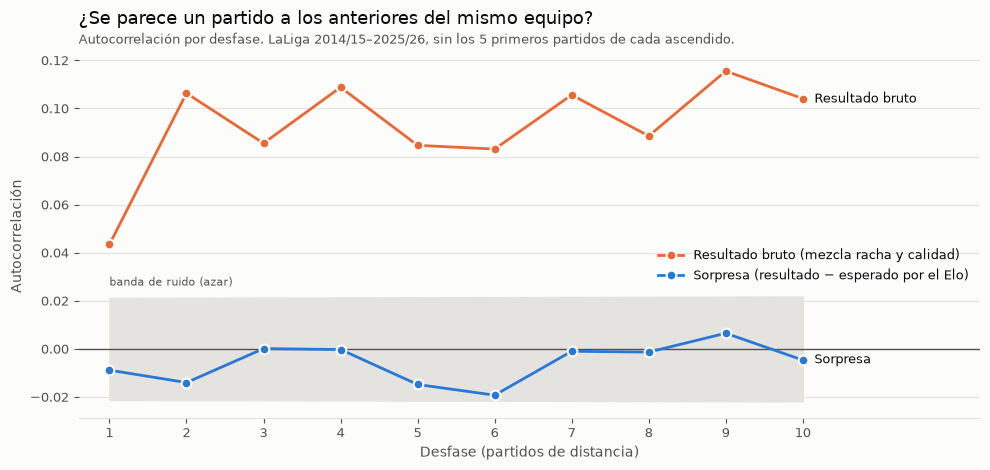

In [18]:
COLOR_BRUTO, COLOR_SORPRESA = "#eb6834", "#2a78d6"
fig, ax = plt.subplots(figsize=(10, 4.8), facecolor=FONDO)
banda = acf_sorpresa.banda_ruido
ax.fill_between(acf_sorpresa.desfase, -banda, banda, color=REJILLA, zorder=0)
ax.axhline(0, color=TINTA_2, linewidth=1)

for datos, color, etiqueta in ((acf_bruto, COLOR_BRUTO, "Resultado bruto (mezcla racha y calidad)"),
                               (acf_sorpresa, COLOR_SORPRESA, "Sorpresa (resultado − esperado por el Elo)")):
    ax.plot(datos.desfase, datos.autocorrelacion, color=color, linewidth=2, marker="o", markersize=7,
            markeredgecolor=FONDO, markeredgewidth=1.5, label=etiqueta, zorder=3)
    ultimo = datos.iloc[-1]
    ax.text(ultimo.desfase + 0.15, ultimo.autocorrelacion, etiqueta.split(" (")[0],
            va="center", fontsize=9, color=TINTA)

ax.text(1, banda.iloc[0] + 0.004, "banda de ruido (azar)", fontsize=8, color=TINTA_2, va="bottom")
ax.set_xticks(acf_sorpresa.desfase)
ax.set_xlim(0.6, 12.3)
ax.set_xlabel("Desfase (partidos de distancia)", color=TINTA_2)
ax.set_ylabel("Autocorrelación", color=TINTA_2)
ax.legend(loc="center right", bbox_to_anchor=(1, 0.42), frameon=False, fontsize=9, labelcolor=TINTA)
ax.set_facecolor(FONDO)
ax.grid(axis="y", color=REJILLA, linewidth=0.8)
ax.set_axisbelow(True)
ax.tick_params(colors=TINTA_2, labelsize=9)
for lado in ("top", "right", "left"):
    ax.spines[lado].set_visible(False)
ax.spines["bottom"].set_color(REJILLA)
ax.set_title("¿Se parece un partido a los anteriores del mismo equipo?", loc="left",
             fontsize=13, color=TINTA, pad=22)
ax.text(0, 1.03, "Autocorrelación por desfase. LaLiga 2014/15–2025/26, sin los 5 primeros partidos de cada ascendido.",
        transform=ax.transAxes, fontsize=9, color=TINTA_2)
fig.tight_layout()
fig.savefig(FIGURES / "02_autocorrelacion_rachas.png", dpi=150, facecolor=FONDO)
plt.show()

El desfase 1 del resultado bruto es mucho más bajo que el resto. Hipótesis: los equipos suelen **alternar** partidos en casa y fuera, así que un partido y el anterior casi siempre se juegan en condiciones distintas, y la ventaja de local los hace menos parecidos. Lo comprobamos separando las parejas según si se jugaron en la misma condición o no:

In [19]:
previo_condicion = serie.groupby(["equipo", "etapa"]).condicion.shift(1)
previo_puntuacion = serie.groupby(["equipo", "etapa"]).puntuacion.shift(1)
previo_ascenso = serie.groupby(["equipo", "etapa"]).periodo_ascenso.shift(1).astype("boolean").fillna(True)
base = previo_puntuacion.notna() & ~serie.periodo_ascenso & ~previo_ascenso

filas = []
for nombre, mascara in (("misma condición (casa-casa o fuera-fuera)", serie.condicion == previo_condicion),
                        ("condición distinta (casa-fuera o fuera-casa)", serie.condicion != previo_condicion)):
    m = base & mascara
    filas.append({"parejas con desfase 1": nombre, "n": int(m.sum()),
                  "autocorrelación resultado bruto": round(np.corrcoef(serie.puntuacion[m], previo_puntuacion[m])[0, 1], 3)})
pd.DataFrame(filas)

,parejas con desfase 1,n,autocorrelación resultado bruto
0,misma condición (casa-casa o fuera-fuera),1172,0.137
1,condición distinta (casa-fuera o fuera-casa),7715,0.029


Confirmado: entre partidos jugados en la misma condición la autocorrelación es 0,137; entre casa y fuera, solo 0,029. La caída del desfase 1 es un efecto del **calendario** (alternancia casa/fuera), no del fútbol.

### ¿Qué anticipa mejor el futuro: los puntos recientes o el xG reciente?

Para cada partido comparamos la **forma** (últimos 5 partidos, sin el actual) con el **rendimiento futuro**: los puntos por partido del actual y los 4 siguientes. Las dos ventanas no se solapan, así que no hay fuga de información.

Incluimos el **Elo** como referencia: indica cuánto anticipa el futuro la fuerza a largo plazo por sí sola.

**Datos:** 2014/15–2025/26, filas con forma completa (5 partidos con puntos y con xG), futuro completo (5 partidos) y fuera del periodo de ascenso.

**Incertidumbre:** las filas no son independientes (dos partidos seguidos comparten 4 de sus 5 partidos de forma), así que las fórmulas habituales exagerarían la precisión. Usamos un **bootstrap por equipo-temporada**: se remuestrean temporadas completas de equipos 1.000 veces, se recalculan las correlaciones y el intervalo del 95 % es el rango que contiene el 95 % central de los resultados.

In [20]:
futuro = con.sql("""
SELECT *,
       avg(puntos)   OVER siguiente AS puntos_futuros,
       count(puntos) OVER siguiente AS n_futuro
FROM forma_equipo
WINDOW siguiente AS (PARTITION BY equipo, etapa ORDER BY fecha, id_partido
                     ROWS BETWEEN CURRENT ROW AND 4 FOLLOWING)
""").df()

d = futuro[(futuro.temporada >= "2014-15") & (futuro.n_forma == 5) & (futuro.n_forma_xg == 5)
           & (futuro.n_futuro == 5) & ~futuro.periodo_ascenso].reset_index(drop=True)
PREDICTORES = {"forma_puntos": "Forma en puntos (últimos 5)",
               "forma_xg_dif": "Forma en xG (últimos 5)",
               "elo_antes": "Elo (fuerza a largo plazo)"}


def correlaciones(df):
    return {nombre: df[col].corr(df.puntos_futuros) for col, nombre in PREDICTORES.items()}


rng = np.random.default_rng(42)
indices = d.groupby(["equipo", "temporada"]).indices
claves = list(indices)
muestras = []
for _ in range(1000):
    elegidas = rng.integers(0, len(claves), len(claves))
    muestras.append(correlaciones(d.iloc[np.concatenate([indices[claves[i]] for i in elegidas])]))
muestras = pd.DataFrame(muestras)

resumen = pd.DataFrame({"correlación con los puntos futuros": pd.Series(correlaciones(d)),
                        "IC 95 % inferior": muestras.quantile(0.025),
                        "IC 95 % superior": muestras.quantile(0.975)}).round(3)
print(f"{len(d)} filas · {len(claves)} equipos-temporada")
resumen

8643 filas · 240 equipos-temporada


,correlación con los puntos futuros,IC 95 % inferior,IC 95 % superior
Forma en puntos (últimos 5),0.359,0.295,0.410
Forma en xG (últimos 5),0.425,0.361,0.471
Elo (fuerza a largo plazo),0.572,0.512,0.615


In [21]:
diferencia = muestras["Forma en xG (últimos 5)"] - muestras["Forma en puntos (últimos 5)"]
print(f"Diferencia xG − puntos: {diferencia.mean():.3f} "
      f"(IC 95 %: {diferencia.quantile(0.025):.3f} a {diferencia.quantile(0.975):.3f}); "
      f"el xG anticipa mejor en el {100 * (diferencia > 0).mean():.0f} % de las remuestras")

Diferencia xG − puntos: 0.065 (IC 95 %: 0.035 a 0.093); el xG anticipa mejor en el 100 % de las remuestras


### Conclusiones: ¿existen las rachas?

**1. El resultado bruto sí se parece a los anteriores** (autocorrelación ≈ 0,04–0,12, por encima de la banda de ruido)… **pero es la trampa de la moneda trucada**: los equipos buenos ganan mucho y los malos pierden mucho. Mide calidad, no racha.

**2. Una vez descontada la calidad con el Elo, la racha desaparece.** La autocorrelación de las sorpresas está **dentro de la banda de ruido en los 10 desfases**. Un resultado inesperado **no** anticipa otro resultado inesperado en el partido siguiente, ni en los 10 siguientes.

Con el matiz ya comentado: el Elo absorbe parte de cualquier racha al actualizarse, y los valores ligeramente negativos (−0,01 a −0,02, dentro del ruido) son justo lo que cabría esperar de ese efecto. La lectura prudente es: **no hay evidencia de rachas más allá de la calidad del equipo; si existen, son demasiado débiles para detectarlas con 12 temporadas.**

**3. Si se quiere medir el "momento", el xG es mejor que los puntos.** La forma en xG anticipa los puntos de los 5 partidos siguientes mejor que la forma en puntos (correlación 0,43 frente a 0,36; la diferencia es positiva en el 100 % de las remuestras del bootstrap). Los resultados recientes llevan más azar que el juego reciente.

**4. Pero la fuerza a largo plazo anticipa mejor que cualquier forma.** El Elo (0,57) supera claramente a las dos formas. Parte de lo que aporta la forma es simplemente que los equipos buenos tienen buena forma.

**Implicación para la fase 4:** la pregunta "¿aporta la forma algo a la fuerza?" apunta a una respuesta modesta. Si la forma añade algo al Elo en el modelo, lo más probable es que sea la forma en **xG**, no la de puntos. Lo comprobaremos allí con validación correcta; aquí solo es una hipótesis.

**Nota de calendario:** la caída del desfase 1 en el resultado bruto se debe a la alternancia casa/fuera. Cualquier análisis de secuencias de partidos debe tener en cuenta la condición de local.

## 5. Evolución del Elo

Seis equipos presentes en todas las temporadas analizadas (2014/15–2025/26; el Villarreal estaba en Segunda en 2012/13 y entra en 2013/14 con el Elo heredado de los descendidos), cada uno en su panel (*small multiples*): con 500 partidos por equipo, seis líneas superpuestas en un solo gráfico serían ilegibles. En gris, el resto de equipos como contexto. Todos los paneles comparten eje vertical para poder compararlos.

La zona sombreada son las temporadas de calentamiento (2012/13–2013/14): el Elo parte de 1500 para todos y aún no es fiable.

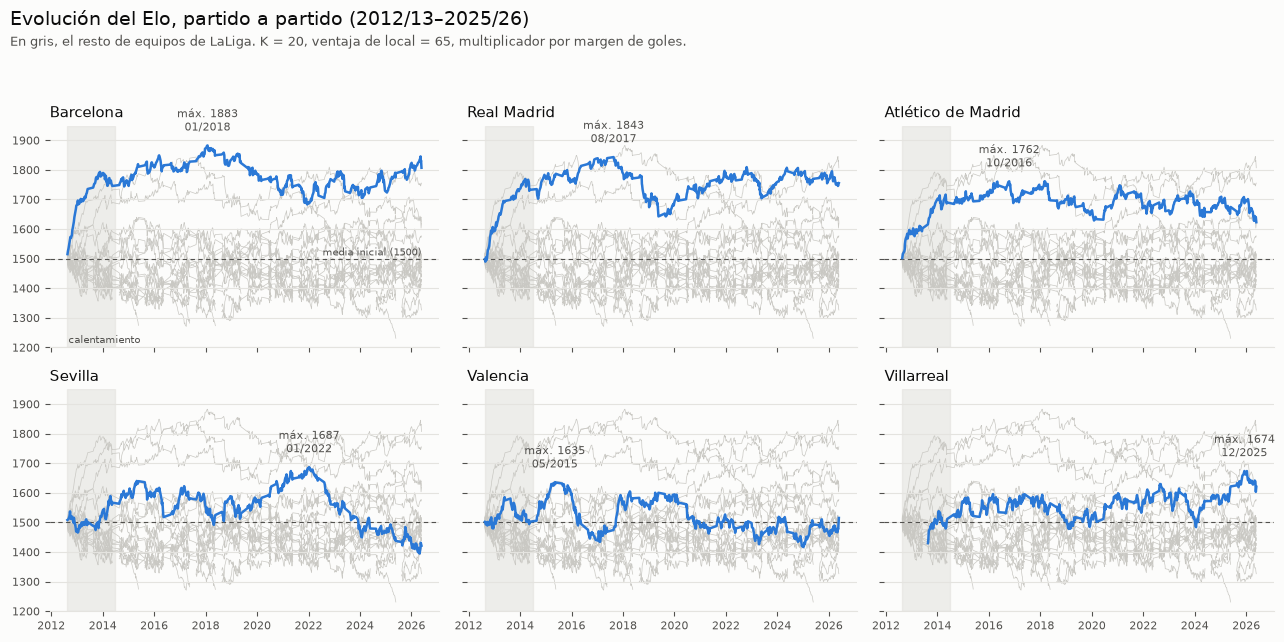

In [22]:
EQUIPOS_GRAFICO = ["Barcelona", "Real Madrid", "Atlético de Madrid", "Sevilla", "Valencia", "Villarreal"]
elo_serie = (elo_largo.merge(con.sql("SELECT id_partido, equipo, etapa FROM forma_equipo").df(),
                             on=["id_partido", "equipo"])
             .sort_values(["equipo", "fecha", "id_partido"]))
fin_calentamiento = pd.Timestamp("2014-07-01")

fig, axes = plt.subplots(2, 3, figsize=(13, 6.5), sharex=True, sharey=True, facecolor=FONDO)
for ax, equipo in zip(axes.flat, EQUIPOS_GRAFICO):
    ax.axvspan(elo_serie.fecha.min(), fin_calentamiento, color=REJILLA, alpha=0.6, zorder=0)
    for otro, datos in elo_serie.groupby(["equipo", "etapa"]):   # por etapa: sin líneas que crucen descensos
        if otro[0] != equipo:
            ax.plot(datos.fecha, datos.elo_despues, color="#c9c8c3", linewidth=0.5, zorder=1)
    datos = elo_serie[elo_serie.equipo == equipo]
    ax.plot(datos.fecha, datos.elo_despues, color=SERIE, linewidth=1.8, zorder=3)
    maximo = datos.loc[datos.elo_despues.idxmax()]
    ax.annotate(f"máx. {maximo.elo_despues:.0f}\n{maximo.fecha:%m/%Y}", xy=(maximo.fecha, maximo.elo_despues),
                xytext=(0, 8), textcoords="offset points", ha="center", va="bottom", fontsize=8, color=TINTA_2)
    ax.set_title(equipo, loc="left", fontsize=11, color=TINTA)
    ax.axhline(1500, color=TINTA_2, linewidth=0.8, linestyle=(0, (4, 3)), zorder=2)
    ax.set_facecolor(FONDO)
    ax.grid(axis="y", color=REJILLA, linewidth=0.8)
    ax.tick_params(colors=TINTA_2, labelsize=8)
    for lado in ("top", "right", "left"):
        ax.spines[lado].set_visible(False)
    ax.spines["bottom"].set_color(REJILLA)

axes[0, 0].text(pd.Timestamp("2012-09-01"), 1215, "calentamiento", fontsize=7, color=TINTA_2)
axes[0, 0].text(elo_serie.fecha.max(), 1503, "media inicial (1500)", fontsize=7, color=TINTA_2, ha="right", va="bottom")
axes[0, 0].set_ylim(1200, 1950)
fig.suptitle("Evolución del Elo, partido a partido (2012/13–2025/26)", x=0.01, ha="left", fontsize=14, color=TINTA)
fig.text(0.01, 0.925, "En gris, el resto de equipos de LaLiga. K = 20, ventaja de local = 65, multiplicador por margen de goles.",
         fontsize=9, color=TINTA_2)
fig.tight_layout(rect=(0, 0, 1, 0.91))
fig.savefig(FIGURES / "02_evolucion_elo.png", dpi=150, facecolor=FONDO)
plt.show()

## 6. Exportación: `forma_elo.csv`

Una fila por equipo y partido, enlazable con `partidos_equipo.csv` por `id_partido` + `equipo`. Es una tabla **separada** porque contiene cálculos nuestros, no datos de las fuentes: si cambiamos el Elo, no se toca la tabla de la fase 1.

Todas las columnas de esta tabla se conocen **antes** del partido (el Elo "después" se excluye a propósito para que no se use por error), salvo las de identificación. Se añaden al diccionario de datos.

In [23]:
forma_elo = con.sql("""
SELECT f.id_partido, f.temporada, f.fecha, f.equipo, f.rival, f.condicion, f.etapa::INTEGER AS etapa,
       f.elo_antes,
       r.elo_antes AS elo_rival_antes,
       CASE f.condicion WHEN 'local' THEN e.puntuacion_esperada_local
                        ELSE 1 - e.puntuacion_esperada_local END AS puntuacion_esperada_elo,
       f.periodo_ascenso,
       f.forma_puntos, f.n_forma,
       f.forma_xg_dif, f.n_forma_xg
FROM forma_equipo f
JOIN forma_equipo r ON r.id_partido = f.id_partido AND r.equipo = f.rival
JOIN elo_partidos_df e ON e.id_partido = f.id_partido
ORDER BY f.id_partido, f.condicion
""").df()
assert len(forma_elo) == 2 * len(partidos_df)
forma_elo.to_csv(PROCESSED / "forma_elo.csv", index=False, encoding="utf-8")

DICCIONARIO_FORMA = {
    "id_partido": ("Identificador del partido (orden cronológico)", "antes"),
    "temporada": ("Temporada, p. ej. 2014-15", "antes"),
    "fecha": ("Fecha oficial del partido", "antes"),
    "equipo": ("Equipo de la fila", "antes"),
    "rival": ("Rival del equipo de la fila", "antes"),
    "condicion": ("'local' o 'visitante' para el equipo de la fila", "antes"),
    "etapa": ("Número de etapa continua del equipo en Primera (se reinicia al volver tras descender)", "antes"),
    "elo_antes": ("Elo del equipo antes del partido (K=20, H=65, margen de goles)", "antes"),
    "elo_rival_antes": ("Elo del rival antes del partido", "antes"),
    "puntuacion_esperada_elo": ("Puntuación esperada por el Elo para el equipo (victoria=1, empate=0,5), con ventaja de local", "antes"),
    "periodo_ascenso": ("True en los 5 primeros partidos de un ascendido (K x 1,5; se excluyen del modelo)", "antes"),
    "forma_puntos": ("Media de puntos en los 5 partidos anteriores de la misma etapa", "antes"),
    "n_forma": ("Partidos que entran en forma_puntos (0-5)", "antes"),
    "forma_xg_dif": ("Media de xG a favor − xG en contra en los 5 partidos anteriores de la misma etapa", "antes"),
    "n_forma_xg": ("Partidos con xG que entran en forma_xg_dif (0-5; 0 antes de 2014-15)", "antes"),
}
assert set(DICCIONARIO_FORMA) == set(forma_elo.columns), "Hay columnas sin documentar"

ruta_diccionario = PROCESSED / "diccionario_datos.csv"
diccionario = pd.read_csv(ruta_diccionario)
diccionario = diccionario[diccionario.fichero != "forma_elo.csv"]          # idempotente al re-ejecutar
nuevas = pd.DataFrame([{"fichero": "forma_elo.csv", "columna": col, "tipo": str(forma_elo[col].dtype),
                        "descripcion": desc,
                        "fuente": "Understat" if "xg" in col else "Calculado",
                        "disponible_desde": "2014-15" if "xg" in col else "2012-13",
                        "momento": f"se conoce {momento} del partido"}
                       for col, (desc, momento) in DICCIONARIO_FORMA.items()])
pd.concat([diccionario, nuevas]).to_csv(ruta_diccionario, index=False, encoding="utf-8")
print(f"forma_elo.csv: {len(forma_elo)} filas · diccionario: {len(diccionario) + len(nuevas)} columnas documentadas")
forma_elo.head(4)

forma_elo.csv: 10640 filas · diccionario: 83 columnas documentadas


,id_partido,temporada,fecha,equipo,rival,condicion,etapa,elo_antes,elo_rival_antes,puntuacion_esperada_elo,periodo_ascenso,forma_puntos,n_forma,forma_xg_dif,n_forma_xg
0,1,2012-13,2012-08-18,Celta de Vigo,Málaga,local,1,1500.0,1500.0,0.592466,False,NaN,0,NaN,0
1,1,2012-13,2012-08-18,Málaga,Celta de Vigo,visitante,1,1500.0,1500.0,0.407534,False,NaN,0,NaN,0
2,2,2012-13,2012-08-18,Mallorca,Espanyol,local,1,1500.0,1500.0,0.592466,False,NaN,0,NaN,0
3,2,2012-13,2012-08-18,Espanyol,Mallorca,visitante,1,1500.0,1500.0,0.407534,False,NaN,0,NaN,0


## Resumen de la fase 2

- **Elo propio** (K = 20, H = 65, margen de goles, ascendidos con A2 + K × 1,5), verificado con 4 pruebas, entre ellas una de fuga de información.
- **Forma** en puntos y en xG (últimos 5 partidos por etapa en Primera), verificada con dos implementaciones independientes y una prueba de fuga.
- **Ventaja de local:** existe siempre; mínima en 2020/21, sin público.
- **Ascendidos:** rinden mejor que los descendidos a los que sustituyen; la regla A2 los infravalora (documentado, no reajustado).
- **Rachas:** descontada la calidad con el Elo, no hay autocorrelación detectable. El xG reciente anticipa mejor los puntos futuros que los puntos recientes, pero el Elo supera a ambas formas.

**Archivos que produce este notebook**

| Archivo | Contenido |
|---|---|
| `data/processed/forma_elo.csv` | Una fila por equipo y partido con **solo información previa**: `elo_antes`, `elo_rival_antes`, `puntuacion_esperada_elo`, `periodo_ascenso`, `forma_puntos`, `forma_xg_dif` y cuántos partidos entran en cada media. No se versiona (contiene xG de Understat): se regenera con este notebook |
| `data/processed/diccionario_datos.csv` | Se añaden las columnas de `forma_elo`, con su momento (antes / después del partido) |
| `reports/figures/02_ventaja_local.png` | Ventaja de local por temporada frente al supuesto H = 65 |
| `reports/figures/02_autocorrelacion_rachas.png` | Autocorrelación del resultado bruto y de la sorpresa (rachas) |
| `reports/figures/02_evolucion_elo.png` | Evolución del Elo de seis equipos |

El código reutilizable del Elo está en [`src/laliga/elo.py`](../src/laliga/elo.py) y se prueba en [`tests/test_elo.py`](../tests/test_elo.py); la forma se recalcula de forma independiente en [`tests/test_forma.py`](../tests/test_forma.py).